In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('datos\\SSNMX_catalogo.csv',skiprows=4,skipfooter=7, engine='python')

In [3]:
# porcentaje de nulos en la columna magnitud
data['Magnitud'] = pd.to_numeric(data['Magnitud'],errors='coerce')
null_percentage = data['Magnitud'].isnull().sum()/len(data)
null_percentage # 0.88!!
# para quitar los valores nulos 
# data.dropna(inplace=True) 
# llenar
# data.fillna({'Magnitud":0, 'Latitud':1})

np.float64(0.8876093965914326)

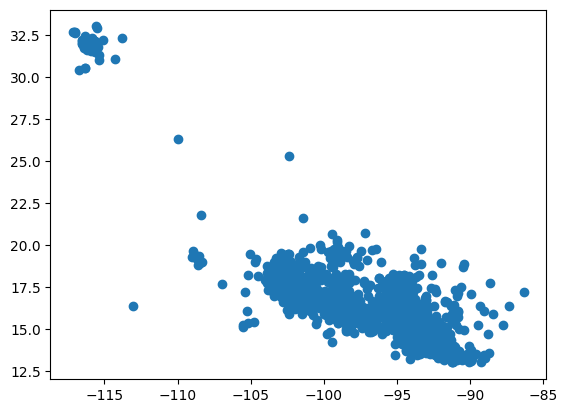

In [6]:
# define classes to fill the NAs accordingly
plt.scatter(data['Longitud'], data['Latitud'])

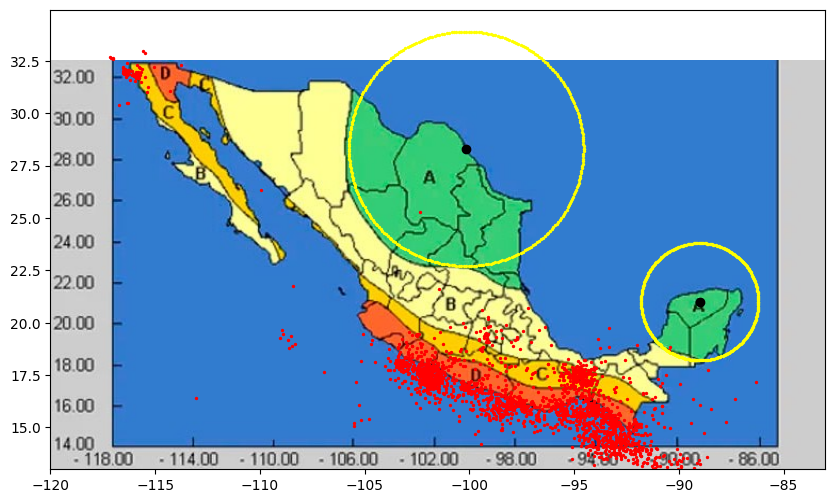

In [ ]:
im = plt.imread('datos//mapa-sismico.jpg')
fig, ax = plt.subplots(figsize=(10,6.5))
map_x_min = -120 #data['Longitud'].min()
map_x_max = -83#data['Longitud'].max()
map_y_min = 13#data['Latitud'].min()
map_y_max = 32.5#data['Latitud'].max()
im = ax.imshow(im, extent=[map_x_min, map_x_max, map_y_min, map_y_max])
plt.scatter(data['Longitud'], data['Latitud'], s=2, color='red')

puntos = 300
centroA1 = [-100.15,28.3]
rA1 = 5.6
anguloA1 = np.linspace(0, 2*np.pi, puntos+1)
xA1 = rA1 * np.cos(anguloA1) + centroA1[0]
yA1 = rA1 * np.sin(anguloA1) + centroA1[1]
plt.scatter(centroA1[0],centroA1[1], color='black')
plt.scatter(xA1,yA1,color='yellow', s=2)

centroA2 = [-89,21]
rA2 = 2.8
anguloA2 = np.linspace(0, 2*np.pi, puntos+1)
xA2 = rA2 * np.cos(anguloA2) + centroA2[0]
yA2 = rA2 * np.sin(anguloA2) + centroA2[1]
plt.scatter(centroA2[0],centroA2[1], color='black')
plt.scatter(xA2,yA2,color='yellow', s=2)

Activy: fill the NAs in region A with central tendency measures of region A 

In [ ]:
regionA1 = data[((data['Longitud'] - centroA1[0])**2 + (data['Latitud'] - centroA1[1])**2)<=rA1**2]
regionA2 = data[((data['Longitud'] - centroA2[0])**2 + (data['Latitud'] - centroA2[1])**2)<=rA2**2]
regionA = data[(((data['Longitud'] - centroA1[0])**2 + (data['Latitud'] - centroA1[1])**2)<=rA1**2) |
               (((data['Longitud'] - centroA2[0])**2 + (data['Latitud'] - centroA2[1])**2)<=rA2**2)]
regionA

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
303,1985-03-07,13:19:07,NaN,18.69,-90.48,33.0,"28 km al NORESTE de ESCARCEGA, CAMP",1985-03-07,19:19:07,revisado
358,1985-03-20,00:48:30,NaN,18.85,-90.41,15.0,"44 km al NORESTE de ESCARCEGA, CAMP",1985-03-20,06:48:30,revisado
1011,1985-08-08,14:57:49,NaN,25.28,-102.36,33.0,"25 km al SUROESTE de PARRAS DE LA FUENTE, COAH",1985-08-08,20:57:49,revisado


### cuadrados

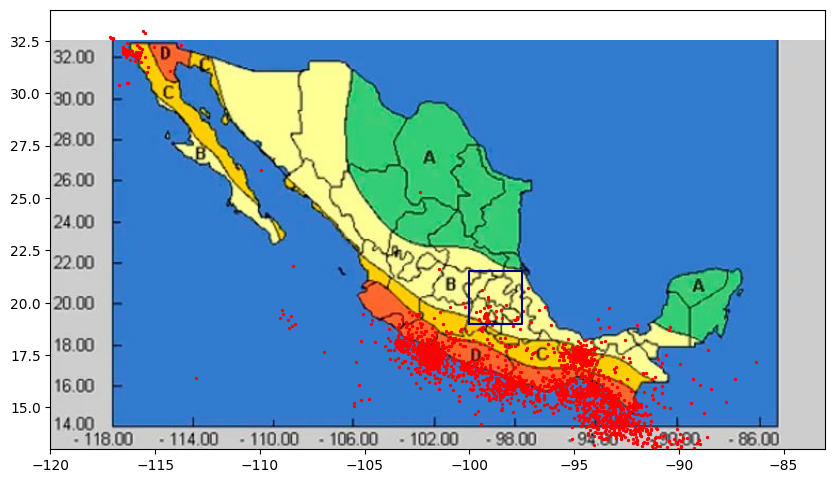

In [49]:
im = plt.imread('datos//mapa-sismico.jpg')
fig, ax = plt.subplots(figsize=(10,6.5))
map_x_min = -120 #data['Longitud'].min()
map_x_max = -83#data['Longitud'].max()
map_y_min = 13#data['Latitud'].min()
map_y_max = 32.5#data['Latitud'].max()
im = ax.imshow(im, extent=[map_x_min, map_x_max, map_y_min, map_y_max])
plt.scatter(data['Longitud'], data['Latitud'], s=2, color='red')

esquina_inf = [-100, 19]
lado = 2.5
x = [esquina_inf[0], esquina_inf[0]+lado, esquina_inf[0]+lado, esquina_inf[0], esquina_inf[0]]
y = [esquina_inf[1], esquina_inf[1], esquina_inf[1]+lado, esquina_inf[1]+lado, esquina_inf[1]]

plt.plot(x, y, color='darkblue')

In [50]:
regionB = data[(data['Longitud'].between(esquina_inf[0],esquina_inf[0]+lado))&
                (data['Latitud'].between(esquina_inf[1],esquina_inf[1]+lado))]
regionB

,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus
88,1985-01-13,06:05:17,NaN,19.26,-98.43,5.0,"3 km al SUR de S MARTIN TEXMELUCAN, PUE",1985-01-13,12:05:17,revisado
273,1985-02-25,22:48:30,NaN,19.06,-98.02,5.0,"3 km al NORESTE de AMOZOC DE MOTA, PUE",1985-02-26,04:48:30,revisado
327,1985-03-11,08:35:04,NaN,20.27,-99.10,15.0,"10 km al NORESTE de PROGRESO, HGO",1985-03-11,14:35:04,revisado
414,1985-04-03,21:18:42,NaN,19.19,-99.53,5.0,"7 km al OESTE de SGO TIANGUISTENCO, MEX",1985-04-04,03:18:42,revisado
415,1985-04-03,21:19:54,NaN,19.22,-99.54,5.0,"6 km al SUR de S MATEO ATENCO, MEX",1985-04-04,03:19:54,revisado
474,1985-04-20,01:23:32,NaN,19.32,-98.75,2.0,"10 km al NORESTE de S MARTIN CUAUTLALPAN, MEX",1985-04-20,07:23:32,revisado
506,1985-04-30,10:02:32,NaN,20.17,-99.11,5.0,"12 km al SURESTE de PROGRESO, HGO",1985-04-30,16:02:32,revisado
874,1985-07-12,19:56:55,NaN,19.90,-98.25,5.0,"16 km al SURESTE de CUAUTEPEC, HGO",1985-07-13,01:56:55,revisado
927,1985-07-24,01:12:59,NaN,20.62,-99.42,5.0,"14 km al SUROESTE de ZIMAPAN, HGO",1985-07-24,07:12:59,revisado
1160,1985-09-03,15:26:49,NaN,19.55,-99.69,5.0,"19 km al NOROESTE de V CUAUHTEMOC, MEX",1985-09-03,21:26:49,revisado


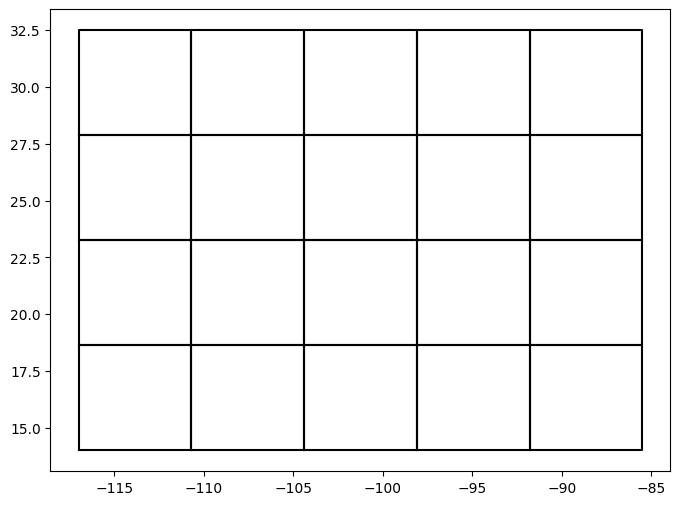

In [41]:
def generar_malla_cuadrados(p_inicio, p_final, cuadros_h, cuadros_v, graficar=True):
    lado_x=(p_final[0]-p_inicio[0])/cuadros_h
    lado_y=(p_final[1]-p_inicio[1])/cuadros_v

    celdas = []

    for i in range(cuadros_h):
        for j in range(cuadros_v):
        # Límites de la celda actual
            min_x = p_inicio[0] + i * lado_x
            max_x = min_x + lado_x
            min_y = p_inicio[1] + j * lado_y
            max_y = min_y + lado_y

            celdas.append({
                'celda_id': f'C_{i}_{j}',
                'columna': i,
                'fila': j,
                'min_lon': min_x,
                'max_lon': max_x,
                'min_lat': min_y,
                'max_lat': max_y,
            })

        # Trazado de las líneas de la celda
            if graficar:
                vx = [min_x, max_x, max_x, min_x, min_x]
                vy = [min_y, min_y, max_y, max_y, min_y]
                plt.plot(vx, vy, color='black')

    return celdas

p_inicio = [-117,14]
p_final = [-85.5,32.5]
cantidad_h = 5
cantidad_y = 4
plt.figure(figsize=(8, 6))
malla = generar_malla_cuadrados(p_inicio, p_final, cantidad_h, cantidad_y,  graficar=True)

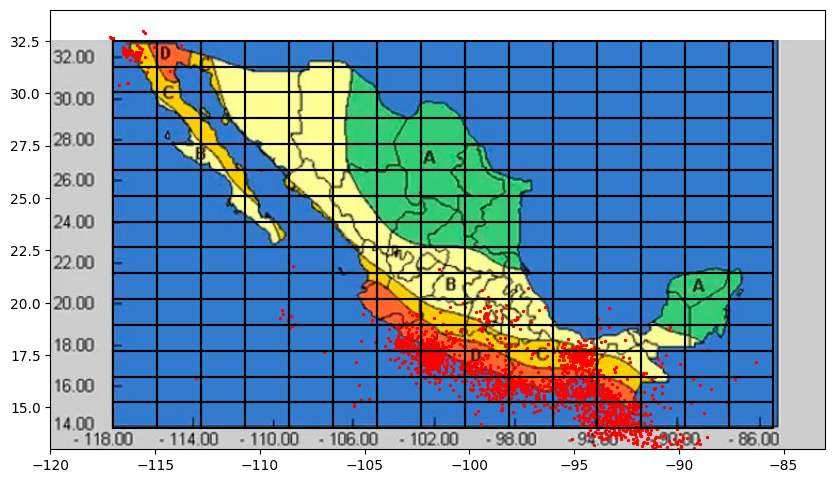

In [55]:
p_inicio = [-117,14]
p_final = [-85.5,32.5]
cantidad_h = 15
cantidad_v = 15

# 2. Generar y graficar la malla
fig, ax = plt.subplots(figsize=(10,6.5))
malla = generar_malla_cuadrados(p_inicio, p_final, cantidad_h, cantidad_v,  graficar=True)

im = plt.imread('datos//mapa-sismico.jpg')

map_x_min = -120 #data['Longitud'].min()
map_x_max = -83#data['Longitud'].max()
map_y_min = 13#data['Latitud'].min()
map_y_max = 32.5#data['Latitud'].max()
im = ax.imshow(im, extent=[map_x_min, map_x_max, map_y_min, map_y_max])
plt.scatter(data['Longitud'], data['Latitud'], s=2, color='red')

In [ ]:
k=0
for i in range(cantidad_h):
    for j in range(cantidad_v):
        celda = malla[k]
        condicion = ((data['Longitud'].between(celda['min_lon'],celda['max_lon'])) &
                (data['Latitud'].between(celda['min_lat'],celda['max_lat'])))
        data.loc[condicion, 'region'] = f'region_{i}_{j}'
        k+=1
print(data['Magnitud'].isna().sum())
data['Magnitud'] = data.groupby('region')['Magnitud'].transform(lambda x: x.fillna(x.median()))

d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\pa

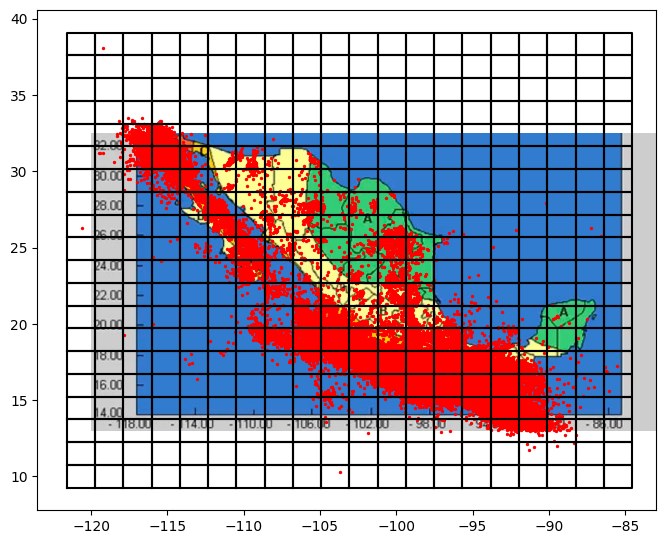

In [83]:
data=pd.read_csv('datos\\SSNMX_largo.csv',skiprows=4,skipfooter=7, engine='python')
data['Magnitud'] = pd.to_numeric(data['Magnitud'],errors='coerce')

p_inicio = [data['Longitud'].min()-1, data['Latitud'].min()-1]
p_final = [data['Longitud'].max()+1, data['Latitud'].max()+1]
cantidad_h = 20
cantidad_v = 20

# 2. Generar y graficar la malla
fig, ax = plt.subplots(figsize=(10,6.5))
malla = generar_malla_cuadrados(p_inicio, p_final, cantidad_h, cantidad_v,  graficar=True)

im = plt.imread('datos//mapa-sismico.jpg')

map_x_min = -120 #data['Longitud'].min()
map_x_max = -83#data['Longitud'].max()
map_y_min = 13#data['Latitud'].min()
map_y_max = 32.5#data['Latitud'].max()
im = ax.imshow(im, extent=[map_x_min, map_x_max, map_y_min, map_y_max])
plt.scatter(data['Longitud'], data['Latitud'], s=2, color='red')

In [84]:
k=0
for i in range(cantidad_h):
        for j in range(cantidad_v):
                celda = malla[k]
                condicion = ((data['Longitud'].between(celda['min_lon'],celda['max_lon'])) &
                        (data['Latitud'].between(celda['min_lat'],celda['max_lat'])))
                data.loc[condicion, 'region'] = f'region_{i}_{j}'
                k+=1
print(data['Magnitud'].isnull().sum())


4483


In [85]:
data['Magnitud'] = data.groupby('region')['Magnitud'].transform(lambda x: x.fillna(x.median()))

print(data['Magnitud'].isnull().sum())

data[data['Magnitud'].isnull()]

7


d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
d:\papeles maestria\ejercicios_maestria_icd\.venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,Fecha,Hora,Magnitud,Latitud,Longitud,Profundidad,Referencia de localizacion,Fecha UTC,Hora UTC,Estatus,region
281,1985-03-02,12:19:54,NaN,17.05,-89.93,33.0,"166 km al SURESTE de TENOSIQUE, TAB",1985-03-02,18:19:54,revisado,region_17_5
1040,1985-08-13,02:17:34,NaN,17.75,-88.61,33.0,"89 km al SUROESTE de CHETUMAL, QR",1985-08-13,08:17:34,revisado,region_17_5
2210,1986-01-06,11:07:44,NaN,14.55,-87.95,33.0,"439 km al SUR de CHETUMAL, QR",1986-01-06,17:07:44,revisado,region_18_3
2589,1986-03-03,05:33:15,NaN,17.20,-89.70,33.0,"186 km al ESTE de TENOSIQUE, TAB",1986-03-03,11:33:15,revisado,region_17_5
2999,1986-05-28,07:33:44,NaN,19.98,-115.93,9.0,"701 km al SUROESTE de CABO SAN LUCAS, BCS",1986-05-28,13:33:44,revisado,region_3_7
4552,1987-11-06,09:11:31,NaN,18.48,-90.08,33.0,"70 km al ESTE de ESCARCEGA, CAMP",1987-11-06,15:11:31,revisado,region_17_6
4570,1987-11-08,22:44:10,NaN,20.32,-91.75,15.0,"138 km al NOROESTE de CAMPECHE, CAMP",1987-11-09,04:44:10,revisado,region_16_7
